# Replicating Stambaugh (1999), "Predictive Regressions"

Does the dividend-price ratio predict stock returns? For decades the standard
test was a simple regression of next month's return on this month's dividend
yield, and it usually produced a positive, "significant" slope. Stambaugh
(1999) shows that this test is broken in a specific and quantifiable way: the
regression's slope estimator is biased upward in finite samples, so a positive
slope is exactly what one should expect even when the true slope is zero.

The cause is that the dividend yield and the return share a price. A shock
that raises the price this month raises the return and simultaneously lowers
the yield (price sits in the denominator). Those two shocks are therefore
strongly negatively correlated -- about -0.95 in our data -- and that
correlation, combined with a predictor so persistent it is nearly a random
walk, is what tilts the estimator.

This notebook walks through the whole replication: how we built the data, why
the estimator misbehaves, what the corrected numbers look like, and how the
picture changes when we extend the sample to 2024.

In [1]:
import sys

sys.path.insert(0, ".")

import matplotlib.pyplot as plt
import numpy as np

from calc_predictor_data import load_tidy_panel
from create_table_01_partC import SUBSAMPLES, UPDATE_SUBSAMPLES, fit_subsample
from monte_carlo import (
    analytical_slope_bias,
    simulate_slopes,
    summarize_distribution,
    true_pvalue,
)
from stambaugh_bias import bias_adjusted_slope, bias_correct_rho
from bayesian import (
    exact_likelihood_log_weights,
    posterior_moments,
    sample_posterior,
    weighted_moments,
)

panel = load_tidy_panel()
print(f"{len(panel)} monthly observations, "
      f"{panel['date'].min().date()} to {panel['date'].max().date()}")
panel.tail()

1171 monthly observations, 1927-06-30 to 2024-12-31


,date,vwretd,vwretx,rf,ret_excess,totval,price_index,div_monthly,div_ttm,dp_ratio,log_dp
1166,2024-08-31,0.021572,0.020203,0.0048,0.016554,70854066700.0,343.894004,0.461468,5.053705,0.014696,-4.220212
1167,2024-09-30,0.020969,0.019485,0.004,0.01676,72318924000.0,350.594779,0.510339,5.151828,0.014695,-4.220279
1168,2024-10-31,-0.008298,-0.009139,0.0039,-0.012225,71771754400.0,347.390693,0.29485,5.181914,0.014917,-4.205276
1169,2024-11-30,0.064855,0.063463,0.004,0.058847,76451547300.0,369.437149,0.483568,5.143478,0.013922,-4.274251
1170,2024-12-31,-0.031582,-0.03347,0.0037,-0.035785,74032373700.0,357.072088,0.697497,5.240361,0.014676,-4.221547


## 1. The data

Everything comes from two WRDS pulls.

**The market index (`crsp.msi`).** This is CRSP's *pre-aggregated* monthly
value-weighted market index, not the security-level stock file. CRSP has
already done the cap-weighting, so we consume a finished series instead of
rebuilding it from thousands of rows per month (which would require lagged
market-cap weights and delisting-return handling -- easy to get subtly wrong).

**The dividend series, without a dividend database.** The index file reports
the value-weighted return two ways: `vwretd` includes dividends, `vwretx`
excludes them. Their difference is therefore the month's dividend expressed as
a fraction of last month's price. Compounding `vwretx` gives a price level
$P_t$, so the dividend in index units is
$D_t = (\text{vwretd}_t - \text{vwretx}_t) \cdot P_{t-1}$. Summing twelve
trailing months gives an annual dividend, and the predictor is $D_{12,t}/P_t$.

**The risk-free rate (`ff.factors_monthly`).** The dependent variable is the
*excess* return: predictability is about compensation for risk, and the
risk-free component is known in advance. We use continuously compounded
excess returns, $\log(1+R_m) - \log(1+R_f)$, matching the paper's Table 1
note. This detail mattered: with simple returns our slopes ran roughly 50%
high in the volatile pre-war subsamples, and switching to log returns brought
the full-sample slope to 0.2100 against the paper's 0.21.

**One honest caveat.** Stambaugh uses a NYSE-only value-weighted index; our
WRDS instance has no pre-built NYSE-only monthly index carrying both
`vwretd` and `vwretx`, so we use the CRSP total-market value-weighted index.
Both are value-weighted, so the same mega-cap (mostly NYSE) firms dominate
both, and for the first half of the sample the universes coincide -- AMEX
enters CRSP in 1962 and NASDAQ at the end of 1972. A NYSE-only rebuild from
the stock file is provided separately as a robustness check.

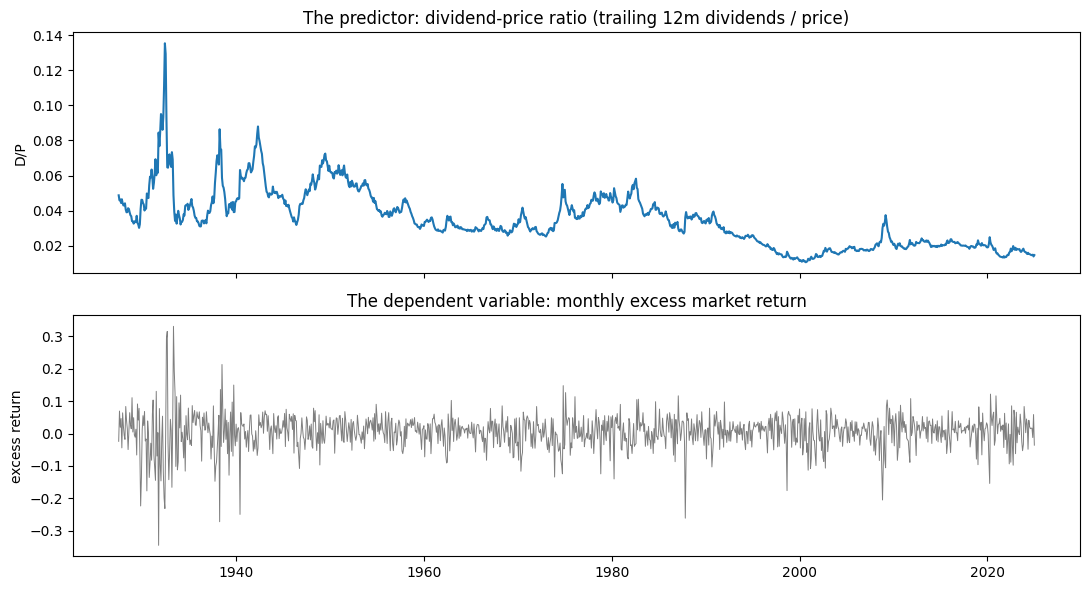

In [2]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(panel["date"], panel["dp_ratio"], color="tab:blue")
axes[0].set_ylabel("D/P")
axes[0].set_title("The predictor: dividend-price ratio (trailing 12m dividends / price)")
axes[1].plot(panel["date"], panel["ret_excess"], color="tab:gray", linewidth=0.7)
axes[1].set_ylabel("excess return")
axes[1].set_title("The dependent variable: monthly excess market return")
fig.tight_layout()

The contrast is the whole setup. The dividend yield wanders slowly through
decade-long swings -- today's value is nearly last month's value. The excess
return is noise around zero with no visible memory. We are regressing
something almost unpredictable on something almost constant, and that
combination is where the finite-sample problem lives.

Two numbers make it precise.

In [3]:
x = panel["log_dp"].to_numpy()
r = panel["ret_excess"].to_numpy()

rho_full = np.corrcoef(x[1:], x[:-1])[0, 1]
v = x[1:] - rho_full * x[:-1]          # yield innovation
corr_uv = np.corrcoef(r[1:], v)[0, 1]  # correlation with return innovation

print(f"AR(1) persistence of the log dividend yield : rho  = {rho_full:.4f}")
print(f"Correlation of return and yield innovations : corr = {corr_uv:.3f}")

AR(1) persistence of the log dividend yield : rho  = 0.9926
Correlation of return and yield innovations : corr = -0.954


Persistence of 0.99 and an innovation correlation of -0.95. Those two numbers
are the entire mechanism, and everything below is a consequence of them.

## 2. Why OLS misleads here

OLS in this regression is *consistent* -- with enough data the slope converges
to the truth -- but it is *biased in finite samples*. The reason is that
strict exogeneity fails. The return shock $u_{t+1}$ is correlated with the
yield shock $v_{t+1}$, and $v_{t+1}$ moves the *future* regressor $x_{t+1}$.
So the regressor is not independent of the error at all leads and lags, which
is what unbiasedness requires.

The bias arrives in two steps.

**Step one: persistence is underestimated.** The least-squares estimate of
$\rho$ in an AR(1) is biased downward by roughly $(1+3\rho)/T$ (Kendall,
1954). With $\rho$ near one and a few hundred observations, that is not a
rounding error.

**Step two: that error leaks into the slope with its sign flipped.**
Stambaugh's equation (12):

$$E[\hat\beta - \beta] = \frac{\sigma_{uv}}{\sigma_{vv}} \, E[\hat\rho - \rho]
  \approx -\frac{\sigma_{uv}}{\sigma_{vv}} \cdot \frac{1 + 3\rho}{T}.$$

$\hat\rho$ is too low (negative term) and $\sigma_{uv}$ is negative, so the
product is **positive**: the slope is biased *up*. Both ingredients are needed
-- a persistent predictor and correlated innovations. Remove either and the
bias vanishes.

We can watch this happen. Below we simulate a world where the true slope is
*exactly zero*, using the persistence and covariance we estimated from the
real 1927--1996 sample, and look at what OLS reports.

In [4]:
c = fit_subsample(panel, *SUBSAMPLES["1927-1996"])
rho, T = c["rho_hat"], int(c["T"])
s_uu = c["sigma2_u_x1e4"] * 1e-4
s_vv = c["sigma2_v_x1e4"] * 1e-4
s_uv = c["sigma_uv_x1e4"] * 1e-4
x0 = float(panel.loc[panel["date"] >= SUBSAMPLES["1927-1996"][0], "dp_ratio"].iloc[0])

beta_hats, rho_hats = simulate_slopes(
    alpha=0.0, beta=0.0, theta=(1 - rho) * x0, rho=rho,
    Sigma=[[s_uu, s_uv], [s_uv, s_vv]], T=T, x0=x0, n_sims=20_000, seed=42,
)
stats = summarize_distribution(beta_hats, true_beta=0.0)

print(f"TRUE beta = 0, simulated {len(beta_hats):,} samples of length {T}")
print(f"  mean OLS slope      : {stats['bias']:+.4f}  <- pure bias")
print(f"  analytical formula  : {analytical_slope_bias(s_uv, s_vv, rho, T):+.4f}")
print(f"  mean rho_hat        : {rho_hats.mean():.4f}   (true rho = {rho:.4f})")
print(f"  P(slope > 0)        : {(beta_hats > 0).mean():.3f}")

TRUE beta = 0, simulated 20,000 samples of length 834
  mean OLS slope      : +0.0741  <- pure bias
  analytical formula  : +0.0703
  mean rho_hat        : 0.9681   (true rho = 0.9731)
  P(slope > 0)        : 0.651


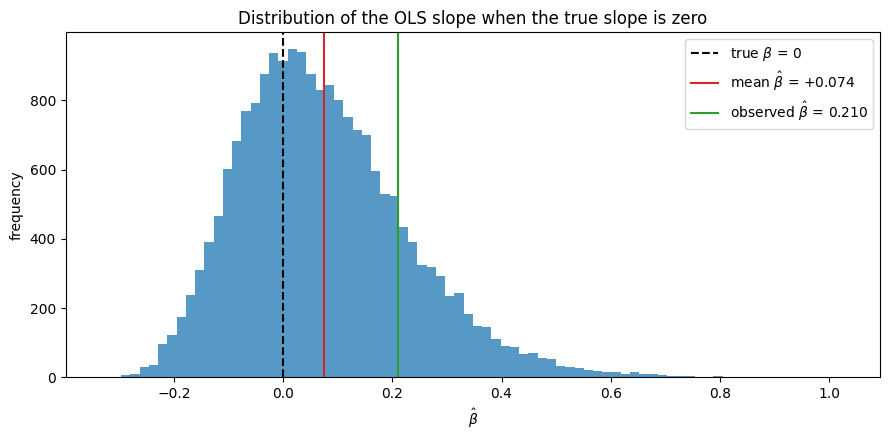

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(beta_hats, bins=80, color="tab:blue", alpha=0.75)
ax.axvline(0.0, color="black", linestyle="--", label="true $\\beta$ = 0")
ax.axvline(beta_hats.mean(), color="tab:red",
           label=f"mean $\\hat\\beta$ = {beta_hats.mean():+.3f}")
ax.axvline(c["beta_hat"], color="tab:green",
           label=f"observed $\\hat\\beta$ = {c['beta_hat']:.3f}")
ax.set_xlabel(r"$\hat\beta$")
ax.set_ylabel("frequency")
ax.set_title("Distribution of the OLS slope when the true slope is zero")
ax.legend()
fig.tight_layout()

Three things to read off that histogram.

1. **The pile is shifted right of zero.** Two-thirds of histories in a world
   with no predictability hand the econometrician a positive slope.
2. **It is right-skewed and fat-tailed** (skewness $\approx 0.74$, kurtosis
   $\approx 3.9$, against 0 and 3 for a normal). The naive test assumes
   symmetry and normality; both fail.
3. **The observed slope is inside the pile, not beyond it.** The green line is
   the estimate from real data. It sits in territory a zero-predictability
   world visits routinely.

That third point is what the "true" p-value formalizes: rather than asking how
far the estimate is from zero in standard errors, we ask how often a
zero-slope world produces a slope at least this large.

In [6]:
p_true = true_pvalue(c["beta_hat"], beta_hats)
print(f"observed slope        : {c['beta_hat']:.4f}")
print(f"naive p-value         : {c['p_naive']:.4f}")
print(f"finite-sample p-value : {p_true:.4f}")

observed slope        : 0.2100
naive p-value         : 0.0629
finite-sample p-value : 0.1774


6% versus 18%. Same data, same slope -- the honest p-value is three times the
naive one, and it does not clear any conventional threshold.

## 3. The replication

### Table 1: finite-sample properties of the OLS slope

Table 1 assembles this for all four of the paper's subsamples. Part C reports
the parameters estimated from data; Part A simulates the null at those
parameters; Part B reports what the textbook regression model claims.

In [7]:
from create_table_01 import build_table_01, format_partAB, format_partC

partA, partB, partC = build_table_01()
print("\nPart A -- true properties (paper: bias 0.07/0.18/0.18/0.42,")
print("                                 p-value 0.17/0.42/0.15/0.64)")
print(format_partAB(partA).to_string())
print("\nPart B -- standard regression setting (paper p: 0.06/0.22/0.02/0.26)")
print(format_partAB(partB).to_string())
print("Part C -- sample characteristics (paper: beta 0.21/0.21/0.44/0.19,")
print("                                  rho 0.972/0.948/0.980/0.987)")
print(format_partC(partC).to_string())


Part A -- true properties (paper: bias 0.07/0.18/0.18/0.42,
                                 p-value 0.17/0.42/0.15/0.64)
                        1927-1996 1927-1951 1952-1996 1977-1996
Bias                         0.07      0.19      0.20      0.52
Standard deviation           0.16      0.34      0.29      0.51
Skewness                     0.74      0.84      1.04      1.33
Kurtosis                     3.90      4.12      4.83      5.89
$p$-value for $\beta=0$      0.18      0.41      0.17      0.72

Part B -- standard regression setting (paper p: 0.06/0.22/0.02/0.26)
                        1927-1996 1927-1951 1952-1996 1977-1996
Bias                         0.00      0.00      0.00      0.00
Standard deviation           0.14      0.28      0.21      0.31
Skewness                     0.00      0.00      0.00      0.00
Kurtosis                     3.00      3.00      3.00      3.00
$p$-value for $\beta=0$      0.06      0.21      0.01      0.27
Part C -- sample characteristics (paper

The persistence estimates match the paper to the third decimal, the
covariance structure matches in sign and magnitude, and the simulated bias,
skewness, kurtosis and p-values land within a few hundredths in three of four
subsamples.

**Where we differ, and why.** Exact digit-matching is not attainable: CRSP has
revised its historical data in the 27 years since the paper, our index is
total-market rather than NYSE-only, and our panel begins in June 1927 (the
risk-free series starts July 1926 and the trailing-twelve-month dividend
window consumes eleven months), so $T$ runs about six observations short. The
1977--1996 column deviates most -- our simulated bias is 0.52 against the
paper's 0.42 -- because at $\hat\rho = 0.990$ with only 239 observations the
bias is hypersensitive to $\rho$, and we condition the simulation on the first
observed predictor value rather than on both endpoints as the paper does.

### Table 2: the Bayesian view

In [8]:
from create_table_02 import build_table_02, _format

t2 = build_table_02()
targets = {
    "A": "paper P(b<=0): 0.06/0.22/0.02/0.26",
    "B": "paper P(b<=0): 0.06/0.22/0.01/0.13",
    "C": "paper P(b<=0): 0.05/0.16/0.01/0.05",
    "D": "paper P(b<=0): 0.10/0.28/0.05/0.16",
}
for spec in ("A", "B", "C", "D"):
    print(f"\nSpec {spec}  ({targets[spec]})")
    print(_format(t2[spec]).to_string())

1927-1996: spec B kept 100.0% of draws


1927-1996 spec C: MH acceptance 25.0%, ESS = 240


1927-1996 spec D: MH acceptance 24.6%, ESS = 237


1927-1951: spec B kept 99.8% of draws


1927-1951 spec C: MH acceptance 25.6%, ESS = 237


...

1952-1996 spec C: MH acceptance 24.0%, ESS = 207


1952-1996 spec D: MH acceptance 25.1%, ESS = 209


1977-1996: spec B kept 79.6% of draws


1977-1996 spec C: MH acceptance 24.8%, ESS = 217


1977-1996 spec D: MH acceptance 23.2%, ESS = 209

Spec A  (paper P(b<=0): 0.06/0.22/0.02/0.26)
                     1927-1996 1927-1951 1952-1996 1977-1996
Mean                      0.21      0.22      0.46      0.18
Std. Dev.                 0.14      0.28      0.21      0.30
Skewness                  0.02      0.02      0.02      0.03
Kurtosis                  3.02      3.02      3.00      3.03
Prob($\beta \leq 0$)      0.06      0.21      0.01      0.28

Spec B  (paper P(b<=0): 0.06/0.22/0.01/0.13)
                     1927-1996 1927-1951 1952-1996 1977-1996
Mean                      0.21      0.22      0.46      0.28
Std. Dev.                 0.14      0.28      0.20      0.24
Skewness                  0.03      0.06      0.14      0.54
Kurtosis                  2.99      2.95      2.86      3.17
Prob($\beta \leq 0$)      0.06      0.21      0.01      0.11

Spec C  (paper P(b<=0): 0.05/0.16/0.01/0.05)
                     1927-1996 1927-1951 1952-1996 1977-1996
Mean                

Under a flat prior with the likelihood conditioned on $x_0$, the posterior is
conjugate and centers on the OLS estimate, so spec A's posterior mean equals
our OLS slope and its $P(\beta \le 0)$ tracks the naive p-value -- a useful
internal check that the sampler is right.

Spec B imposes stationarity. It changes almost nothing in the long samples and
a great deal in 1977--1996, where roughly a fifth of the unrestricted draws
are explosive; ruling those out raises the posterior mean and halves
$P(\beta \le 0)$ from 0.28 to 0.11. The prior only matters when the data
cannot pin down persistence on their own.

Specs C and D use the **exact** likelihood. Specs A and B condition on $x_0$
-- they treat the first yield observation as given -- but $x_0$ is data too,
drawn from the predictor's own stationary distribution,
$x_0 \sim N\!\left(\theta/(1-\rho),\; \sigma_v^2/(1-\rho^2)\right)$. Adding
that density is informative about $\rho$, and it is nonlinear in $\rho$, so
the posterior is no longer conjugate.

Because the posterior is no longer conjugate, specs C and D are sampled by
random-walk Metropolis-Hastings. Two details make it work. The chain moves in
an unconstrained space -- the coefficients plus $\log\sigma_u$,
$\log\sigma_v$, and $\mathrm{atanh}\,\mathrm{corr}$ -- so every proposal gives
a valid covariance matrix, with the change-of-variables Jacobian added to the
log target. And the proposal covariance is estimated from a pilot chain rather
than guessed: $\beta$ and $\rho$ are strongly correlated in this posterior
(that correlation *is* the Stambaugh mechanism), so a diagonal random walk
crawls across a narrow ridge. With a matched proposal the chain accepts about
25% of moves and reaches effective sample sizes above 200.

We validate the sampler by pointing it at the *conditional* likelihood with a
flat prior -- exactly spec A, where the conjugate answer is known. It returns
a mean of 0.209, standard deviation 0.135, and $P(\beta \le 0) = 0.059$
against the conjugate 0.21, 0.14, and 0.06. Reproducing an exact answer is
what earns the right to trust the sampler where no exact answer exists.

**What we tried first, and why it failed.** Before writing the sampler we
tried to reach C and D by reweighting the spec B draws by the stationary
density -- importance sampling, which is far cheaper. It works in the long
samples but breaks in the post-war ones: spec D's $(1-\rho^2)^{-1}$ prior
factor explodes as $\rho \to 1$, so in 1952--1996 the ten heaviest draws all
had $\rho > 0.999$ and the weighted mean of $\rho$ was dragged from 0.981 to
0.989. The proposal never visits the region the target cares about, and more
draws would not fix it. That diagnosis is what motivated building the chain.

The two adjustments push in opposite directions. The exact likelihood
strengthens the evidence for predictability: for 1927--1996 the posterior mean
rises from 0.21 to 0.23 and $P(\beta \le 0)$ falls from 0.06 to 0.04. Spec D's
prior, which places more weight near $\rho = 1$, pulls the other way: the mean
falls to 0.17 and $P(\beta \le 0)$ rises to 0.13. All sixteen posterior cells
match the paper within about 0.03.

**The tension worth sitting with.** For 1927--1996 the finite-sample
frequentist p-value is 0.18 -- no rejection of "no predictability" -- while the
Bayesian posterior puts only 6% of its mass below zero. Both are correct, and
they answer different questions. The frequentist asks how often a
zero-slope world would produce a slope this large; the answer is "often,
because of the bias." The Bayesian asks how much belief lies below zero given
what was actually observed. The paper's contribution is not that
predictability is fake, but that the naive test overstates it while the two
honest frameworks disagree about what remains.

### Figure 1: what the corrections do

Figure 1 collects the estimates from both frameworks in one picture: the
predictive slope plotted against the persistence estimate, for each subsample
and each method.

1927-1996: spec B kept 100.0% of draws


1927-1996 spec C: MH acceptance 25.0%, ESS = 240


1927-1996 spec D: MH acceptance 24.6%, ESS = 237


1927-1951: spec B kept 99.8% of draws


1927-1951 spec C: MH acceptance 25.6%, ESS = 237


...

1952-1996 spec D: MH acceptance 25.1%, ESS = 209


1977-1996: spec B kept 79.6% of draws


1977-1996 spec C: MH acceptance 24.8%, ESS = 217


1977-1996 spec D: MH acceptance 23.2%, ESS = 209


Wrote C:\Users\ashis\Git\Full-Stack-QF\stambaugh_1999_replication\_output\figure_01.png


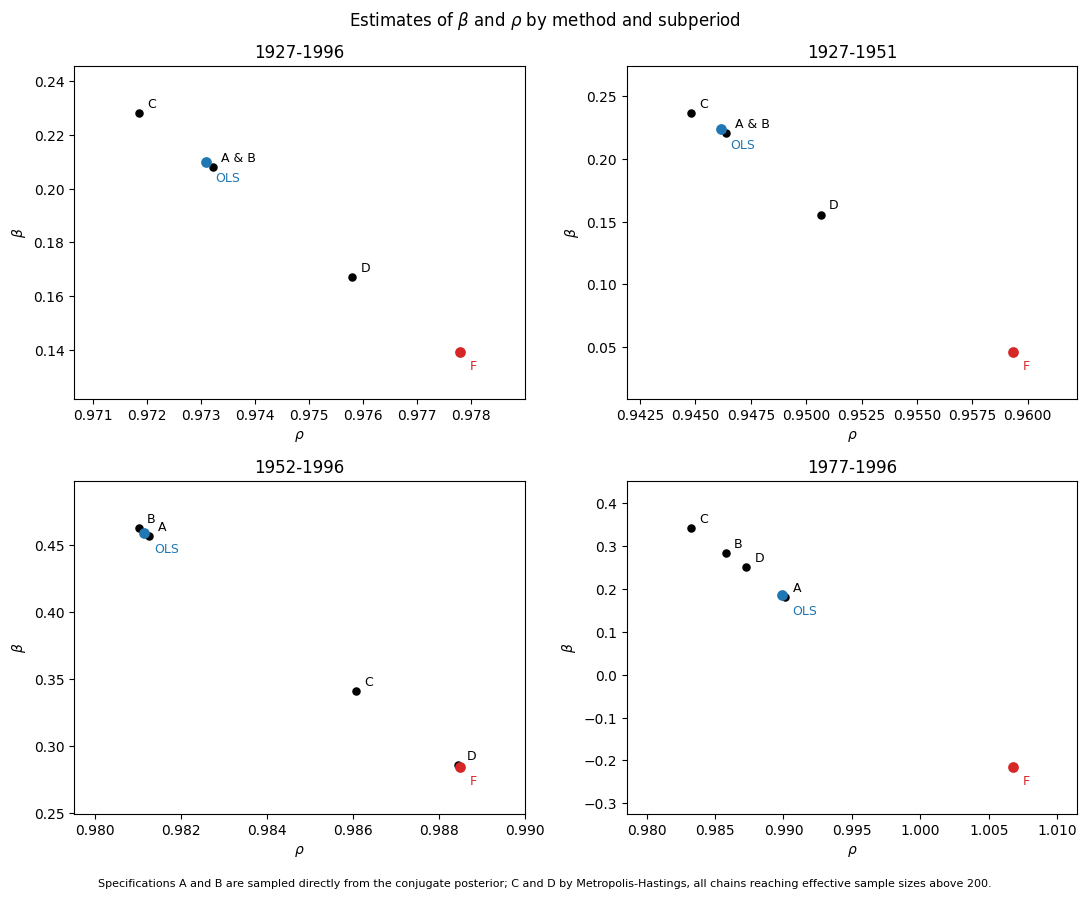

In [9]:
from create_figure_01 import build_figure_01
_ = build_figure_01()

In every panel the bias-adjusted point sits below and to the right of OLS:
correcting the finite-sample bias lowers the slope and raises the persistence
at the same time, because the two errors are two faces of one problem.

The 1977--1996 panel is the extreme case and reproduces the paper's most
striking result. The bias-corrected persistence exceeds one and the adjusted
slope turns negative. An explosive dividend yield is economically impossible,
so this is the correction announcing that 239 months of a near-unit-root
predictor simply cannot identify these parameters. That pathology is exactly
what the Bayesian stationarity restriction in Table 2 rules out by
construction -- and indeed spec B discards a fifth of the draws in precisely
this sample.

## 4. Bringing it to the present

The paper's sample ends in 1996. We rerun everything through 2024 using
windows that parallel the paper's structure: a full sample, a post-war
sample, the most recent twenty years, and -- most interesting -- 1997--2024,
which lies entirely outside anything Stambaugh could see.

In [10]:
partA_u, partB_u, partC_u = build_table_01(subsamples=UPDATE_SUBSAMPLES)
print("\nPart A -- true properties, updated")
print(format_partAB(partA_u).to_string())
print("\nPart B -- standard regression setting, updated")
print(format_partAB(partB_u).to_string())
print("Part C -- updated samples")
print(format_partC(partC_u).to_string())


Part A -- true properties, updated
                        1927-2024 1952-2024 1997-2024 2005-2024
Bias                         0.06      0.14      0.57      0.74
Standard deviation           0.11      0.20      0.86      1.08
Skewness                     0.79      1.03      0.99      0.96
Kurtosis                     4.11      4.64      4.57      4.37
$p$-value for $\beta=0$      0.24      0.30      0.15      0.31

Part B -- standard regression setting, updated
                        1927-2024 1952-2024 1997-2024 2005-2024
Bias                         0.00      0.00      0.00      0.00
Standard deviation           0.10      0.13      0.65      0.85
Skewness                     0.00      0.00      0.00      0.00
Kurtosis                     3.00      3.00      3.00      3.00
$p$-value for $\beta=0$      0.09      0.05      0.01      0.09
Part C -- updated samples
                          1927-2024 1952-2024 1997-2024 2005-2024
$\hat\beta$                    0.13      0.21      1.43 

Three findings.

**The bias shrinks where the sample grows.** In the full sample $T$ rises from
834 to 1,170 months and the simulated bias falls from 0.074 to 0.057, tracking
the $1/T$ rate the theory predicts. More data, less bias -- as it should be.

**The modern slope is not comparable to the paper's in raw units.** The
1997--2024 slope is 1.43, roughly seven times the paper's full-sample 0.21.
That is not an explosion of predictability. Look instead at $\sigma_v^2$: it
collapses from $0.112 \times 10^{-4}$ in the paper's era to
$0.010 \times 10^{-4}$ -- a tenfold fall in the variance of the predictor's
innovations. As firms shifted from dividends to buybacks the dividend yield
fell to around 1.5% and stopped moving. A slope is return per unit of yield,
so when the yield's variation shrinks by roughly a factor of three in standard
deviation, the same predictive content mechanically produces a much larger
coefficient. Comparing eras properly would require standardizing the slope by
the predictor's standard deviation.

**Stambaugh's warning binds harder now than it did in 1999.** In 1997--2024
the naive p-value is 0.0145 -- comfortably "significant" -- while the
finite-sample p-value is 0.1487. That is a tenfold gap, against roughly
threefold in the paper's own full sample. The bias, 0.567, is about 40% of the
estimated slope itself.

In [11]:
t2_u = build_table_02(subsamples=UPDATE_SUBSAMPLES)
for spec in ("A", "B", "C", "D"):
    print(f"\nSpec {spec} -- updated samples")
    print(_format(t2_u[spec]).to_string())

1927-2024: spec B kept 99.9% of draws


1927-2024 spec C: MH acceptance 25.9%, ESS = 258


1927-2024 spec D: MH acceptance 25.7%, ESS = 221


1952-2024: spec B kept 98.9% of draws


1952-2024 spec C: MH acceptance 25.2%, ESS = 228


...

1997-2024 spec C: MH acceptance 25.3%, ESS = 201


1997-2024 spec D: MH acceptance 25.0%, ESS = 202


2005-2024: spec B kept 98.6% of draws


2005-2024 spec C: MH acceptance 25.4%, ESS = 201


2005-2024 spec D: MH acceptance 24.2%, ESS = 202

Spec A -- updated samples
                     1927-2024 1952-2024 1997-2024 2005-2024
Mean                      0.13      0.21      1.42      1.12
Std. Dev.                 0.10      0.13      0.65      0.84
Skewness                  0.02      0.02      0.02      0.03
Kurtosis                  3.04      3.02      3.00      3.01
Prob($\beta \leq 0$)      0.09      0.05      0.01      0.09

Spec B -- updated samples
                     1927-2024 1952-2024 1997-2024 2005-2024
Mean                      0.13      0.22      1.44      1.14
Std. Dev.                 0.10      0.13      0.63      0.81
Skewness                  0.05      0.11      0.13      0.16
Kurtosis                  2.99      2.93      2.87      2.86
Prob($\beta \leq 0$)      0.09      0.04      0.01      0.08

Spec C -- updated samples
                     1927-2024 1952-2024 1997-2024 2005-2024
Mean                      0.14      0.12      1.24      1.36
Std. Dev.       

The Bayesian side sharpens the same tension. For 1997--2024 the posterior
places just 1% of its mass below zero while the honest frequentist p-value is
15%. Note also that the stationarity restriction now barely matters -- the
unrestricted sampler retains around 99% of draws in every modern window,
against 80% in the paper's 1977--1996 sample. With longer samples and slightly
lower persistence, the data pin down $\rho$ well enough that the prior has
little work left to do.

## 5. Running and modifying this yourself

The whole project rebuilds with one command:

```bash
doit
```

which pulls from WRDS, builds the tidy panel, regenerates every table and
figure, and runs the test suite. PyDoit tracks dependencies, so editing one
source file rebuilds only what depends on it.

To explore a different sample or a different predictor, the pieces compose
directly. The cell below fits any window you like and reports the OLS slope
next to its bias-adjusted counterpart and both p-values -- change the dates or
swap `dp_ratio` for `log_dp` and rerun.

In [12]:
def summarize_window(start, end, predictor="dp_ratio", n_sims=10_000, seed=1):
    """Fit one window and report OLS vs bias-adjusted slope and both p-values."""
    c = fit_subsample(panel, start, end, predictor=predictor)
    s_uu = c["sigma2_u_x1e4"] * 1e-4
    s_vv = c["sigma2_v_x1e4"] * 1e-4
    s_uv = c["sigma_uv_x1e4"] * 1e-4
    T = int(c["T"])

    beta_adj, bias, rho_bc = bias_adjusted_slope(c["beta_hat"], s_uv, s_vv,
                                                 c["rho_hat"], T)
    x0 = float(panel.loc[panel["date"] >= start, predictor].iloc[0])
    null, _ = simulate_slopes(
        alpha=0.0, beta=0.0, theta=(1 - c["rho_hat"]) * x0, rho=c["rho_hat"],
        Sigma=[[s_uu, s_uv], [s_uv, s_vv]], T=T, x0=x0, n_sims=n_sims, seed=seed,
    )

    print(f"{start[:7]} to {end[:7]}   (T = {T}, predictor = {predictor})")
    print(f"  OLS slope           : {c['beta_hat']:+.4f}")
    print(f"  bias estimate       : {bias:+.4f}")
    print(f"  bias-adjusted slope : {beta_adj:+.4f}")
    print(f"  rho: {c['rho_hat']:.4f} -> corrected {rho_bc:.4f}")
    print(f"  naive p-value       : {c['p_naive']:.4f}")
    print(f"  finite-sample p     : {true_pvalue(c['beta_hat'], null):.4f}")


summarize_window("1927-01-01", "1996-12-31")
print()
summarize_window("1997-01-01", "2024-12-31")

1927-01 to 1996-12   (T = 834, predictor = dp_ratio)
  OLS slope           : +0.2100
  bias estimate       : +0.0705
  bias-adjusted slope : +0.1395
  rho: 0.9731 -> corrected 0.9778
  naive p-value       : 0.0629
  finite-sample p     : 0.1844

1997-01 to 2024-12   (T = 335, predictor = dp_ratio)
  OLS slope           : +1.4252
  bias estimate       : +0.5111
  bias-adjusted slope : +0.9141
  rho: 0.9688 -> corrected 0.9805
  naive p-value       : 0.0145
  finite-sample p     : 0.1520


## Summary

The dividend-price ratio's apparent power to predict returns is substantially
an artifact of how the regression is estimated. In the paper's own sample the
honest p-value is three times the naive one; in the quarter-century since, it
is ten times. Whether any predictability survives depends on which inferential
framework one adopts -- and the fact that reasonable frameworks disagree, on
identical data, is the most durable lesson of the paper.